# Import libraries

In [245]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# Load annotation

### Load full ground truth

In [246]:
with open("../data/charades/annotations/charades.json", "r") as f:
    gt = json.load(f)

rows_gt = []
for video_id, info in gt["database"].items():
    duration = info["duration"]
    subset = info["subset"]
    for s in info["annotations"]:
        rows_gt.append(
            {
                "video_id": video_id,
                "duration": duration,
                "subset": subset,
                "start": s["segment"][0],
                "end": s["segment"][1],
                "label": s["label"],
            }
        )

gt_df = pd.DataFrame(rows_gt)
gt_df.head()

,video_id,duration,subset,start,end,label
0,7UPGT,23.21,training,16.0,22.2,Someone is laughing
1,7UPGT,23.21,training,16.0,22.2,Someone is smiling
2,7UPGT,23.21,training,15.0,20.0,Closing a refrigerator
3,7UPGT,23.21,training,14.0,23.0,Holding a cup/glass/bottle of something
4,7UPGT,23.21,training,0.0,5.0,Opening a refrigerator


In [247]:
gt_df.shape

(66500, 6)

# Load ground truth function

In [272]:
def load_gt(gt_fname):
    with open(gt_fname) as f:
        gt = json.load(f)

    rows_gt = []
    for video_id, info in gt["database"].items():
        duration = info["duration"]
        subset = info["subset"]
        for s in info["annotations"]:
            rows_gt.append(
                {
                    "video_id": video_id,
                    "duration": duration,
                    "subset": subset,
                    "start": s["segment"][0],
                    "end": s["segment"][1],
                    "label": s["label"],
                }
            )

    return pd.DataFrame(rows_gt)

### Load sample ground truth (10 least frequent classes)

In [280]:
least_sample_gt_df = load_gt("../data/charades/annotations/least_sample_charades.json")
print(least_sample_gt_df.shape)
least_sample_gt_df.head()

(449, 6)


,video_id,duration,subset,start,end,label
0,028CE,20.00,training,2.0,11.0,Fixing a vacuum
1,03EW0,31.12,training,0.0,2.6,Throwing a box somewhere
2,06EDS,35.46,training,23.6,36.0,Making a sandwich
3,08AQS,32.33,training,29.1,33.0,Throwing a box somewhere
4,08LOY,28.04,testing,5.7,21.9,Fixing a light


### Load sample ground truth (10 most frequent classes)

In [ ]:
most_sample_gt_df = load_gt("../data/charades/annotations/most_sample_charades.json")
print(most_sample_gt_df.shape)
most_sample_gt_df.head()

(14697, 6)


,video_id,duration,subset,start,end,label
0,001YG,30.62,training,25.0,30.8,Someone is standing up from somewhere
1,001YG,30.62,training,0.0,32.0,Sitting in a chair
2,004QE,30.58,training,14.2,22.5,Drinking from a cup/glass/bottle
3,004QE,30.58,training,0.0,32.0,Holding a cup/glass/bottle of something
4,004QE,30.58,training,9.9,21.3,Someone is standing up from somewhere


### Load predictions

In [281]:
with open("../exps/charades/actionformer_i3d_rgb/result_detection.json", "r") as f:
  predictions = json.load(f)

rows_predictions = []
for video_id, segments in predictions['results'].items():
  for s in segments:
    rows_predictions.append({
      'video_id': video_id,
      'start': s['segment'][0],
      'end': s['segment'][1],
      'label': s['label'],
      'score': s['score']
    })
  
predictions_df = pd.DataFrame(rows_predictions)
predictions_df.sample(10)

,video_id,start,end,label,score
51952,N0G70,-0.00,3.82,Standing on a chair,0.0012
38871,ICQUJ,7.71,8.88,Fixing a light,0.0010
14906,4RT06,27.70,28.90,Laughing at a picture,0.0011
69130,URAIM,27.70,28.84,Throwing a broom somewhere,0.0050
3177,1QP1S,23.44,24.58,Washing a window,0.0075
42753,J59UP,17.41,18.61,Washing a mirror,0.0053
49740,MME0V,26.46,27.63,Washing a mirror,0.0140
62140,RJZ3I,5.03,6.25,Washing a mirror,0.0072
36224,HDCT0,25.69,27.00,Making a sandwich,0.0053
33750,GLSU2,28.69,29.95,Washing a mirror,0.0022


In [282]:
predictions_df.shape

(81318, 5)

# Plot Predictions against Ground Truth

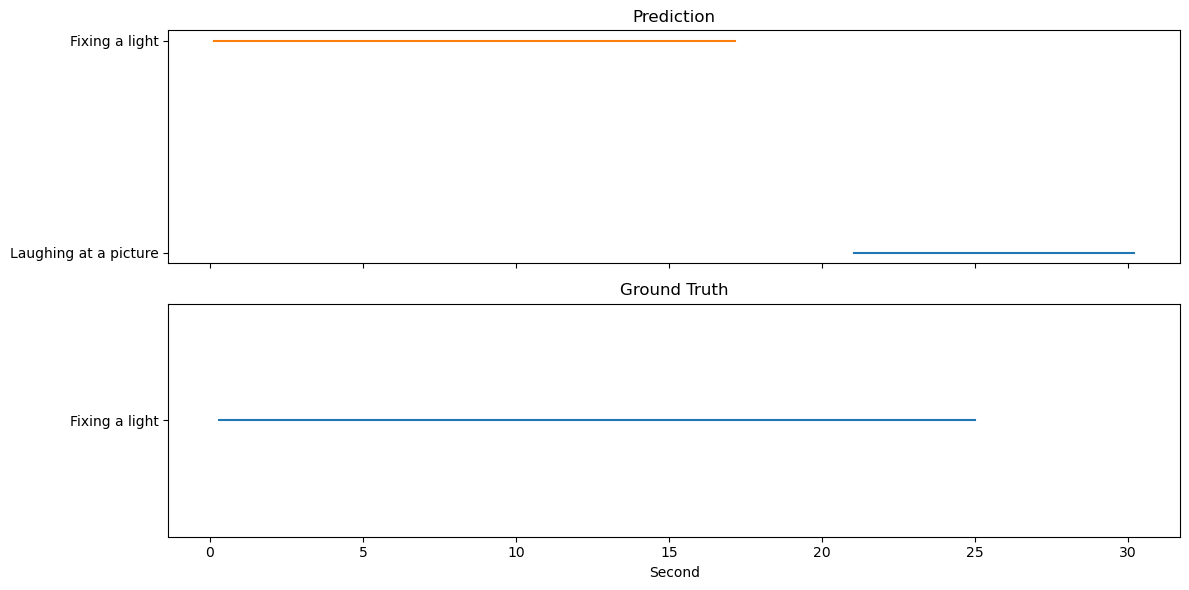

In [283]:
video_id = "G2JR9"
confidence_threshold = 0.04

# predictions for the video
predicted_video = predictions_df[(predictions_df['video_id'] == video_id) & (predictions_df['score'] > confidence_threshold)]
# ground truth for the video
video = gt_df_sample[gt_df_sample['video_id'] == video_id]

# Plot predictions against ground truth
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for _, row in predicted_video.iterrows():
  ax[0].plot([row['start'], row['end']], [row['label']] * 2)
ax[0].set_title('Prediction') 
  
for _, row in video.iterrows():
  ax[1].plot([row['start'], row['end']], [row['label']] * 2)
ax[1].set_title('Ground Truth')

plt.xlabel('Second')  
plt.tight_layout()
plt.show()

# Overlapping Analysis

In [256]:
def calculate_overlap_density(df, video_id):
    # Filter rows for the given video
    video_df = df[df["video_id"] == video_id].copy()

    if len(video_df) < 2:
        return 0.0  # No overlap possible with fewer than 2 segments

    # Get total video duration (assume all rows have the same duration)
    total_duration = video_df["duration"].iloc[0]

    # Build a list of (start, end) tuples
    intervals = list(zip(video_df["start"], video_df["end"]))

    # Create a timeline of second-level granularity
    timeline = [0.0] * int(total_duration * 10)  # use deci-seconds for precision

    # Mark timeline per action
    for start, end in intervals:
        for t in range(int(start * 10), int(end * 10)):
            if 0 <= t < len(timeline):
                timeline[t] += 1

    # Count overlapping time points (where >1 action occurs)
    overlap_count = sum(1 for t in timeline if t > 1)

    # Convert back to seconds
    overlap_duration = overlap_count / 10.0

    # Compute and return overlap density
    return overlap_duration / total_duration

In [268]:
sample_gt_df['overlap_density'] = sample_gt_df['video_id'].apply(lambda x: calculate_overlap_density(sample_gt_df, x))
sample_gt_df['overlap_density'].describe()

count    449.000000
mean       0.058398
std        0.193416
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        0.999458
Name: overlap_density, dtype: float64